# Импорты и настройка

In [159]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pubchempy as pcp
import time
from rdkit import Chem
import warnings
warnings.filterwarnings('ignore')

In [160]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

In [161]:
PATH_TRAIN = r'D:\studies\hack\data\daimler_mixtures_train.csv'
PATH_TEST = r'D:\studies\hack\data\daimler_mixtures_test.csv'
PATH_PROPS = r'D:\studies\hack\data\daimler_component_properties.csv'

In [162]:
rename_map = {
    'scenario_id': 'scenario_id', 'Компонент': 'component', 'Наименование партии': 'batch',
    'Массовая доля, %': 'mass_share', 'Температура испытания | ASTM D445 Daimler Oxidation Test (DOT), °C': 'temp',
    'Время испытания | - Daimler Oxidation Test (DOT), ч': 'time',
    'Delta Kin. Viscosity KV100 - relative | - Daimler Oxidation Test (DOT), %': 'target_visc',
    'Oxidation EOT | DIN 51453 Daimler Oxidation Test (DOT), A/cm': 'target_oxid',
    'Количество биотоплива | - Daimler Oxidation Test (DOT), % масс': 'biofuel',
    'Дозировка катализатора, категория': 'catalyst'
}

In [163]:
train_df = pd.read_csv(PATH_TRAIN).rename(columns=rename_map)
test_df = pd.read_csv(PATH_TEST).rename(columns=rename_map)
prop_df = pd.read_csv(PATH_PROPS)

In [164]:
train_df

,scenario_id,component,batch,mass_share,temp,time,target_visc,target_oxid,biofuel,catalyst
0,train_1,Антиоксидант_5,32,70.832,160,168,25.4,98.04,0,1
1,train_1,Антиоксидант_6,13799.21,70.832,160,168,25.4,98.04,0,1
2,train_1,Антипенная_присадка_3,б/н,3.991,160,168,25.4,98.04,0,1
3,train_1,Базовое_масло_10,0285.21,60.034,160,168,25.4,98.04,0,1
4,train_1,Базовое_масло_17,без номера,84.281,160,168,25.4,98.04,0,1
...,...,...,...,...,...,...,...,...,...,...
2225,train_167,Базовое_масло_1,01595.25,43.229,160,168,-37.0,41.93,0,1
2226,train_167,Базовое_масло_5,01624.25,22.895,160,168,-37.0,41.93,0,1
2227,train_167,Детергент_1,01558.25,8.080,160,168,-37.0,41.93,0,1
2228,train_167,Загуститель_1,01609.25,2.675,160,168,-37.0,41.93,0,1


In [165]:
prop_df

,Компонент,Наименование партии,Наименование показателя,Единица измерения_по_партиям,Значение показателя
0,Детергент_4,0338.22,"Кинематическая вязкость, при 100°C, ASTM D445",мм²/с,16.68
1,Детергент_4,0338.22,"Массовая доля кальция, ASTM D6481",% масс,6.144
2,Детергент_4,0338.22,"Массовая доля цинка, ASTM D6481",% масс,0.0064
3,Детергент_4,0338.22,"Щелочное число, ASTM D2896",мг KOH/г,168
4,Противоизносная_присадка_8,0186.22,"Кинематическая вязкость, при 100°C, ASTM D445",мм²/с,13.74
...,...,...,...,...,...
2636,Базовое_масло_8,typical,"Содержание серы, мг/кг",NaN,<10
2637,Базовое_масло_4,typical,"Содержание серы, мг/кг",NaN,<10
2638,Базовое_масло_16,typical,Содержание ароматики,NaN,<3
2639,Базовое_масло_14,typical,Содержание ароматики,NaN,<3


In [166]:
test_df

,scenario_id,component,batch,mass_share,temp,time,biofuel,catalyst
0,test_1,Антиоксидант_4,01050.22,95.918,160,168,0,1
1,test_1,Базовое_масло_1,03197.24,43.340,160,168,0,1
2,test_1,Базовое_масло_1,03197.24,43.229,160,168,0,1
3,test_1,Базовое_масло_5,03159.24,22.895,160,168,0,1
4,test_1,Детергент_1,03052.24,8.080,160,168,0,1
...,...,...,...,...,...,...,...,...
519,test_40,Базовое_масло_5,02510.25,12.549,160,168,5,2
520,test_40,Депрессорная_присадка_1,0862.24,43.971,160,168,5,2
521,test_40,Детергент_1,01777.25,91.514,160,168,5,2
522,test_40,Загуститель_3,п. B118590651,94.025,160,168,5,2


In [167]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2230 entries, 0 to 2229
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   scenario_id  2230 non-null   object 
 1   component    2230 non-null   object 
 2   batch        2228 non-null   object 
 3   mass_share   2230 non-null   float64
 4   temp         2230 non-null   int64  
 5   time         2230 non-null   int64  
 6   target_visc  2230 non-null   float64
 7   target_oxid  2230 non-null   float64
 8   biofuel      2230 non-null   int64  
 9   catalyst     2230 non-null   int64  
dtypes: float64(3), int64(4), object(3)
memory usage: 174.3+ KB


In [168]:
prop_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2641 entries, 0 to 2640
Data columns (total 5 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   Компонент                     2641 non-null   object
 1   Наименование партии           2635 non-null   object
 2   Наименование показателя       2557 non-null   object
 3   Единица измерения_по_партиям  1835 non-null   object
 4   Значение показателя           2557 non-null   object
dtypes: object(5)
memory usage: 103.3+ KB


In [169]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524 entries, 0 to 523
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   scenario_id  524 non-null    object 
 1   component    524 non-null    object 
 2   batch        524 non-null    object 
 3   mass_share   524 non-null    float64
 4   temp         524 non-null    int64  
 5   time         524 non-null    int64  
 6   biofuel      524 non-null    int64  
 7   catalyst     524 non-null    int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 32.9+ KB


In [170]:
print(f"Сценариев в Train: {train_df['scenario_id'].nunique()}")
print(f"Сценариев в Test: {test_df['scenario_id'].nunique()}")
print(f"Всего записей свойств: {len(prop_df)}")

Сценариев в Train: 167
Сценариев в Test: 40
Всего записей свойств: 2641


# 1. Анализ целевых показателей 

Посмотрим на распределение метрик, которые нам предстоит предсказывать.

In [171]:
scenarios_df = train_df.groupby('scenario_id').first().reset_index()

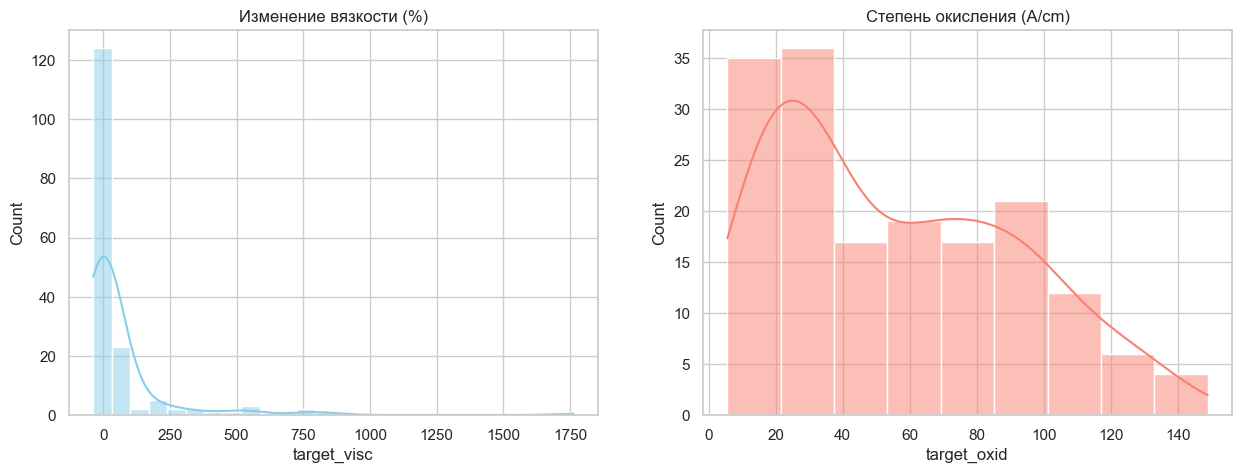

In [172]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(scenarios_df['target_visc'], kde=True, ax=axes[0], color='skyblue').set_title('Изменение вязкости (%)')
sns.histplot(scenarios_df['target_oxid'], kde=True, ax=axes[1], color='salmon').set_title('Степень окисления (A/cm)')
plt.show()

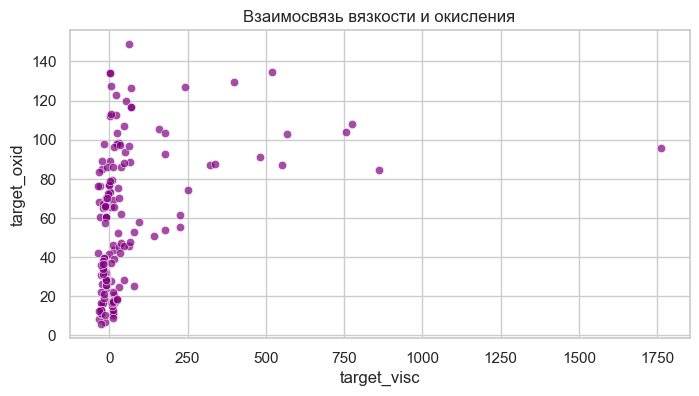

In [173]:
plt.figure(figsize=(8, 4))
sns.scatterplot(data=scenarios_df, x='target_visc', y='target_oxid', alpha=0.7, color='purple')
plt.title('Взаимосвязь вязкости и окисления')
plt.show()

In [174]:
print("Сценарии с максимальным изменением вязкости:")
display(scenarios_df.sort_values('target_visc', ascending=False)[['scenario_id', 'target_visc', 'temp', 'time', 'catalyst']].head())

Сценарии с максимальным изменением вязкости:


,scenario_id,target_visc,temp,time,catalyst
9,train_107,1763.34,150,216,1
8,train_106,861.54,150,168,1
13,train_110,775.51,150,216,1
21,train_118,754.93,150,216,1
148,train_82,566.53,150,216,1


**Выводы по таргетам:**
* Распределение имеет экстремальный "тяжелый правый хвост" со скачками до 1763%. Модели потребуется робастная функция потерь, чтобы выбросы не сломали градиенты.
* Распределение асимметрично, четко выраженный пик (20–40 A/cm) и широкое плато (80–110 A/cm), что подтверждает наличие разных физико-химических режимов течения теста.
* Высокое окисление - необходимое, но не достаточное условие для потери вязкости (есть много точек с высоким окислением, но нулевой вязкостью). Рост вязкости зависит от конкретной химии присадок.

# 2. Анатомия рецептур и температурный парадокс
Анализ состава смесей и выявление главного катализатора деградации масел.

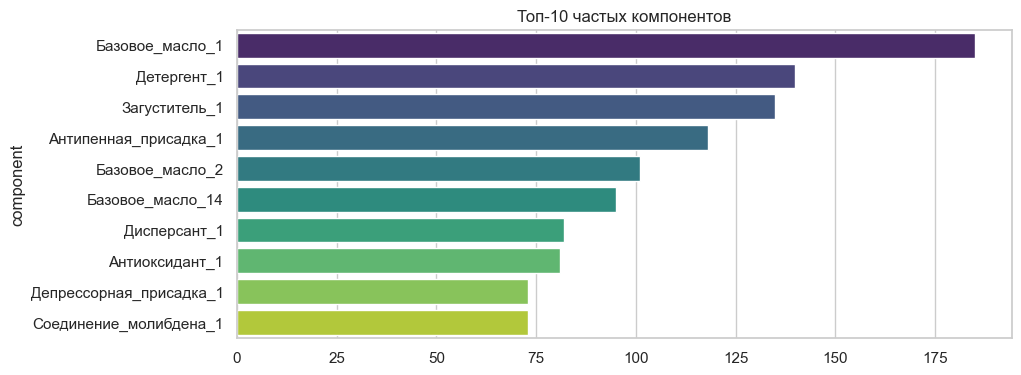

In [176]:
top_components = train_df['component'].value_counts().head(10)
plt.figure(figsize=(10, 4))
sns.barplot(x=top_components.values, y=top_components.index, palette='viridis')
plt.title('Топ-10 частых компонентов')
plt.show()

In [177]:
bio_temp = scenarios_df.groupby(['temp', 'biofuel']).size().unstack(fill_value=0)
print("Распределение Биотоплива по Температурам")
bio_temp

Распределение Биотоплива по Температурам


biofuel,0,5,7
temp,,,
150,1,0,27
154,0,0,2
160,115,14,8


In [178]:
gold = scenarios_df[(scenarios_df['temp'] == 150) & (scenarios_df['biofuel'] == 0)]
print(f"Контрольный сценарий (150°C, 0% biofuel). Вязкость: {gold['target_visc'].values[0]}%")

Контрольный сценарий (150°C, 0% biofuel). Вязкость: 15.22%


**Выводы по рецептурам и условиям:**
* Почти во всех смесях есть базовая основа (`Базовое_масло_1`, `Детергент_1`, `Загуститель_1`). Разрушение масла - вина не одного компонента, а несовместимости коктейля присадок.
* При 150°C вязкость в среднем выше, чем при 160°C. Анализ показал причину: при 150°C почти всегда добавлено 7% биотоплива. 
* Биотопливо является более сильным катализатором деградации, чем сама температура (подтверждено контрольным сценарием с 15%). Модель должна получить этот признак как приоритетный.

# 3. Математика масс и поиск синергии
Проверяем гипотезу о том, что массовые доли можно трактовать как проценты, и ищем нелинейные эффекты взаимодействия компонентов.

In [179]:
mass_sums = train_df.groupby('scenario_id')['mass_share'].sum()
print(f"Сумма масс варьируется от {mass_sums.min():.1f} до {mass_sums.max():.1f}")
print(f"Корреляция суммы масс с окислением: {mass_sums.corr(scenarios_df.set_index('scenario_id')['target_oxid']):.3f}")

Сумма масс варьируется от 247.2 до 956.4
Корреляция суммы масс с окислением: 0.056


In [180]:
target_ids = ['train_106', 'train_117', 'train_107', 'train_118']
comp_comp = train_df[train_df['scenario_id'].isin(target_ids)].pivot_table(
    index='component', columns='scenario_id', values='mass_share').sort_index()

In [182]:
comp_comp.dropna(thresh=2)

scenario_id,train_106,train_107,train_117,train_118
component,,,,
Антиоксидант_2,38.014,38.014,38.014,38.014
Антипенная_присадка_1,3.991,3.991,3.991,3.991
Базовое_масло_1,38.413,38.413,38.413,38.413
Базовое_масло_14,84.281,84.281,84.281,84.281
Базовое_масло_4,18.485,18.485,18.485,18.485
Базовое_масло_8,52.846,52.846,52.846,52.846
Депрессорная_присадка_2,43.971,43.971,43.971,43.971
Детергент_1,31.092,31.092,31.092,31.092
Дисперсант_1,74.243,74.243,NaN,NaN


In [183]:
scenarios_df[scenarios_df['scenario_id'].isin(target_ids)][['scenario_id', 'target_visc']]

,scenario_id,target_visc
8,train_106,861.54
9,train_107,1763.34
20,train_117,482.89
21,train_118,754.93


In [184]:
comp_A, comp_B = 'Детергент_1', 'Антиоксидант_1'
s_A = train_df[(train_df['component'] == comp_A) & (~train_df['scenario_id'].isin(train_df[train_df['component'] == comp_B]['scenario_id']))]['scenario_id']
s_B = train_df[(train_df['component'] == comp_B) & (~train_df['scenario_id'].isin(train_df[train_df['component'] == comp_A]['scenario_id']))]['scenario_id']
s_Both = train_df[(train_df['component'] == comp_A) & (train_df['scenario_id'].isin(train_df[train_df['component'] == comp_B]['scenario_id']))]['scenario_id']

In [185]:
ox_A = scenarios_df[scenarios_df['scenario_id'].isin(s_A)]['target_oxid'].mean()
ox_B = scenarios_df[scenarios_df['scenario_id'].isin(s_B)]['target_oxid'].mean()
ox_Both = scenarios_df[scenarios_df['scenario_id'].isin(s_Both)]['target_oxid'].mean()

In [187]:
print(f"Синергия: {comp_A} и {comp_B}")
print(f"Окисление (Только А): {ox_A:.1f} | Окисление (Только Б): {ox_B:.1f} | Вместе: {ox_Both:.1f}")

Синергия: Детергент_1 и Антиоксидант_1
Окисление (Только А): 62.7 | Окисление (Только Б): 40.0 | Вместе: 50.8


**Выводы по массам и взаимодействиям:**
* Суммарная масса рецептуры - это математический шум (корреляция с таргетом всего 0.05). Использовать абсолютные значения напрямую нельзя, обязательна нормализация.
* Сравнение сценариев train_107 и train_118 (идентичные условия: 150°C, 216ч, 7% биотоплива) показало: замена Дисперсанта_4 на Дисперсант_1 поднимает вязкость с 754% до 1763%.
* Анализ пар присадок (Детергент + Антиоксидант) показывает, что итоговое окисление смеси не вычисляется простым сложением свойств компонентов. Эффекты нелинейны.
* Модели необходимы химические признаки (SMILES) для понимания разницы между присадками.

# 4. Аудит физических свойств и химический паспорт (SMILES)
Проверка второго файла с лабораторными замерами и извлечение молекулярных структур.

In [188]:
prop_df.columns = ['component', 'batch', 'param', 'unit', 'value']

In [189]:
unit_check = prop_df.groupby('param')['unit'].nunique()
multi_units = unit_check[unit_check > 1]
if not multi_units.empty:
    print("Свойства с РАЗНЫМИ единицами измерения:")
    display(prop_df[prop_df['param'].isin(multi_units.index)][['param', 'unit']].drop_duplicates())

Свойства с РАЗНЫМИ единицами измерения:


,param,unit
20,"Индекс вязкости, ГОСТ 25371",–
21,"Испаряемость по NOACK, ASTM D5800",%
363,"Плотность при 15°С, ASTM D4052",кг/м³
2006,"Плотность при 15°С, ASTM D4052",г/см³
2584,"Индекс вязкости, ГОСТ 25371",-
2595,"Испаряемость по NOACK, ASTM D5800",% масс


In [190]:
def ext_meth(t):
    m = re.search(r'(ASTM D\d+|DIN \d+|ГОСТ \d+)', str(t))
    return m.group(1) if m else "NoMethod"

In [191]:
prop_df['method'] = prop_df['param'].apply(ext_meth)
prop_df['base_p'] = prop_df['param'].apply(lambda x: re.sub(r',? (ASTM D\d+|DIN \d+|ГОСТ \d+).*', '', str(x)).strip())

In [192]:
tbn = prop_df[prop_df['base_p'] == 'Щелочное число']
tbn_val = pd.to_numeric(tbn['value'].str.replace(',','.').str.extract(r'(\d+\.?\d*)')[0], errors='coerce')
print("Конфликт методов измерения (щелочное число)")
tbn.assign(val=tbn_val).dropna(subset=['val']).groupby('method')['val'].agg(['mean', 'count'])

Конфликт методов измерения (щелочное число)


,mean,count
method,,
ASTM D2896,154.519211,76
ГОСТ 11362,103.393500,20


In [193]:
def is_smiles(val):
    s = str(val)
    return len(s) > 15 and 'C' in s and ('(' in s or '=' in s) and not re.search(r'[А-Яа-я]', s)

In [194]:
smiles_cnt = prop_df['value'].apply(is_smiles).sum()
cas_cnt = prop_df[prop_df['param'].str.contains('CAS', na=False)]['component'].nunique()

In [195]:
print(f"Химическая инвентаризация")
print(f"Найдено готовых формул SMILES: {smiles_cnt} (в основном детергенты)")
print(f"Найдено CAS-номеров для парсинга из PubChem: {cas_cnt}")

Химическая инвентаризация
Найдено готовых формул SMILES: 22 (в основном детергенты)
Найдено CAS-номеров для парсинга из PubChem: 75


**Выводы**
1. Плотность измеряется в г/см^3 и кг/м^3 (ошибка в 1000 раз).
2. Щелочное число измерено разными методами (ASTM и ГОСТ) с разницей в 50%. Их строго запрещено усреднять - в модель они должны подаваться как разные фичи.
3. Для 100% компонентов можно восстановить молекулярную структуру (через готовые SMILES, парсинг PubChem по CAS или шаблоны классов). Это позволит рассчитать квантовые дескрипторы RDKit (`mol_wt`, `logp`, количество колец).